```text
Model diagnostics
├── Import & Setup
├── Champion-Challenger definition
├── Explainability
└── Fairness   
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import explain_model
from src.feature_engineering import create_target_def12
from src.metrics import my_threshold_metrics
from src.modelling import apply_pipe_PD
from src.plots import my_calibration
from src.preprocessing import my_input_load

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = my_input_load(2019, 2020)
portfolio, dr_summary = create_target_def12(portfolio)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


## Champion - Challenger definition

In this notebook i address the topics of model **explainability** and **fairness** where:
1. Champion: Logistic Regression model
1. Challenger: Gradient Boosting model

In [4]:
# import pipelines

import joblib
pipeline_champ = joblib.load("../models/PIPELINE_PD_ver_012.pkl")
pipeline_chall = joblib.load("../models/PIPELINE_PD_ver_012_GB.pkl")

In [5]:
# apply pipelines

portfolio_champ = apply_pipe_PD(portfolio, pipeline_champ, calculate_el=True)
portfolio_chall = apply_pipe_PD(portfolio, pipeline_chall, calculate_el=True)

## Explainability

**Which are the largest contributors for the champion and challenger models?**

1. Champion model (Logistic Regression): New Customer, Credit Score, Home Ownership, Age, Previous Repayments.
2. Challenger model (Gradient Boosting): Credit Score, Age, Loan Duration, Language Code, Home Ownership, Previous Repayments.

Model type:  LogisticRegression


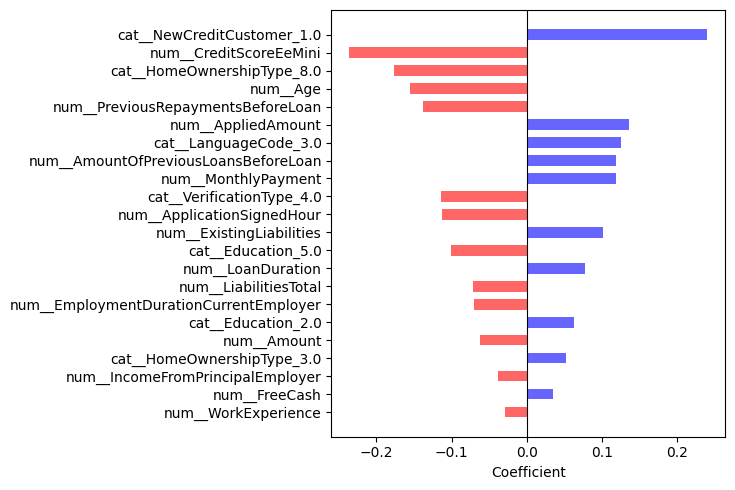

Model type:  XGBClassifier


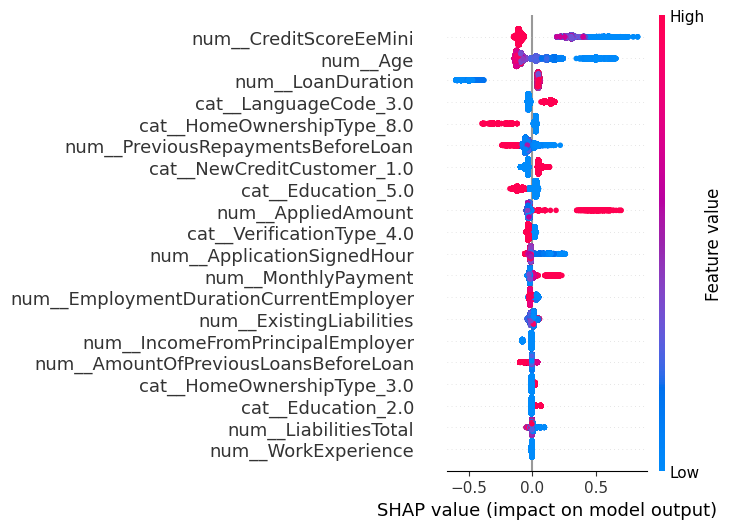

In [6]:
# Global

explanation_champ = explain_model(pipeline_champ, portfolio)
explanation_chall = explain_model(pipeline_chall, portfolio)


## Fairness

**How fair is the champion model regarding new and not-new credit customers?:** 
1. New customers have higher observed default rates and higher predicted PDs than existing customers. Consequently, the PD threshold results in a lower acceptance rate for new customers. However, the accepted portfolios show very similar EL rates across the two groups (2.14% vs 2.12%), suggesting that the difference in approval rates is primarily associated with differences in observed risk rather than an unexplained disparity in portfolio risk.
1. This analysis does not establish that the model is fully fair. It provides a descriptive assessment of group-level prediction and decision outcomes. Further fairness assessment would require consideration of additional groups and, where appropriate, group-level calibration and error metrics.

In [7]:
# create datasets

portfolio_champ_0 = portfolio_champ[portfolio_champ["NewCreditCustomer"]==0]
portfolio_champ_1 = portfolio_champ[portfolio_champ["NewCreditCustomer"]==1]


Champion: New Customer NO
--------------------------------------------------------------
Metric                               All         Threshold
--------------------------------------------------------------
Acceptance Rate                  100.00%            91.13%
Mean PD                           0.1264            0.1147
Exposure                      60,709,678        51,715,550
Mean Exposure                      2,254             2,107
EL                             1,519,869         1,104,450
EL Rate                            2.50%             2.14%
Implied LGD                       19.80%            18.62%
Default Rate                      12.48%            11.37%
----------------------------------------


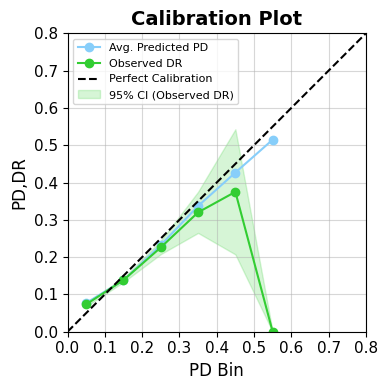

----------------------------------------

Champion: New Customer YES
--------------------------------------------------------------
Metric                               All         Threshold
--------------------------------------------------------------
Acceptance Rate                  100.00%            68.92%
Mean PD                           0.1794            0.1419
Exposure                      55,672,607        33,996,234
Mean Exposure                      2,588             2,293
EL                             1,489,117           721,359
EL Rate                            2.67%             2.12%
Implied LGD                       14.91%            14.95%
Default Rate                      17.72%            13.65%
----------------------------------------


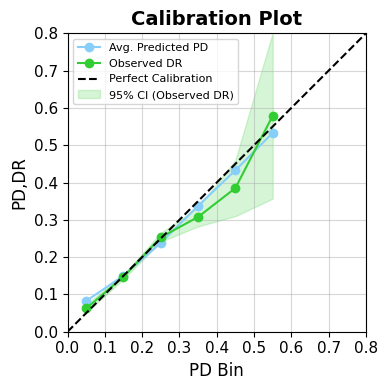

----------------------------------------


In [8]:
# compare champion model predictions against observations
# and derive metrics on PD-threshold

# - New Customer NO
my_threshold_metrics(portfolio_champ_0["default12"], portfolio_champ_0["PD"], 
                        0.20, portfolio_champ_0["Amount"], portfolio_champ_0["EL"], 
                        dataset_name="Champion: New Customer NO")
my_calibration(portfolio_champ_0["default12"], portfolio_champ_0["PD"], bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

# - New Customer YES
my_threshold_metrics(portfolio_champ_1["default12"], portfolio_champ_1["PD"], 
                        0.20, portfolio_champ_1["Amount"], portfolio_champ_1["EL"], 
                        dataset_name="Champion: New Customer YES")
my_calibration(portfolio_champ_1["default12"], portfolio_champ_1["PD"], bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])